<a href="https://colab.research.google.com/github/SumonMaiti/Predict-and-Optimize-Antenna-Parameter-using-ML/blob/main/Antenna_ML_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📡 Prediction and Optimization of Antenna Parameters Using Machine Learning

**Final Year Project — Sub-6 GHz Microstrip Patch Antenna**

---

### 🎯 Project Objective
- **Predict** Bandwidth (BW) and Gain for given antenna geometry parameters
- **Optimize** Xrad, Yrad, Xcenter, Ycenter to maximize both BW (target > 7) and Gain simultaneously

### 📥 Input Parameters (Features)
| Parameter | Description |
|-----------|-------------|
| Xrad | X-radius of the slot/patch |
| Yrad | Y-radius of the slot/patch |
| Xcenter | X-center position |
| Ycenter | Y-center position |

### 📤 Output Parameters (Targets)
| Parameter | Description | Goal |
|-----------|-------------|------|
| BW | Bandwidth (GHz) | **Maximize (minimum > 7)** |
| GAIN | Antenna Gain (dBi) | **Maximize** |

---

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install any missing libraries
!pip install scikit-learn xgboost pandas numpy matplotlib seaborn scipy -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Optimization
from scipy.optimize import differential_evolution

# Display
from IPython.display import display
pd.set_option('display.float_format', '{:.4f}'.format)

# Reproducibility
np.random.seed(42)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Upload & Load the Dataset

> **Instructions:** Run the cell below. A file chooser will appear — upload your `B1_Data_Added_CSV.csv` file.

In [3]:
from google.colab import files

print('📤 Please upload your B1_Data_Added_CSV.csv file below...')
uploaded = files.upload()

📤 Please upload your B1_Data_Added_CSV.csv file below...


Saving B1_Data_Added_CSV.csv to B1_Data_Added_CSV.csv


In [4]:
# Load the uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f'✅ Dataset loaded: {filename}')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()
print('First 5 rows:')
display(df.head())

✅ Dataset loaded: B1_Data_Added_CSV.csv
📊 Shape: 161 rows × 6 columns

First 5 rows:


,Xrad,Yrad,Xcenter,Ycenter,BW,GAIN
0,8.0000,6.7000,0.3000,11.0000,2.4600,0.0700
1,8.1000,5.1000,0.3000,11.0000,5.8800,0.8100
2,8.2000,6.7000,0.3000,11.0000,2.4200,-0.0500
3,8.3000,5.4000,0.4000,13.8000,1.9800,0.2300
4,8.4000,5.6000,1.3000,13.7000,4.1800,0.2690


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [5]:
print('='*55)
print('        DATASET STATISTICAL SUMMARY')
print('='*55)
display(df.describe().T)

print()
print('Missing values per column:')
print(df.isnull().sum())

# How many rows achieve BW > 7?
bw_above_7 = df[df['BW'] > 7]
print(f'\n🎯 Rows with BW > 7: {len(bw_above_7)} out of {len(df)} ({100*len(bw_above_7)/len(df):.1f}%)')
print(f'   Maximum BW in dataset: {df["BW"].max():.4f}')
print(f'   Maximum GAIN in dataset: {df["GAIN"].max():.4f}')

        DATASET STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Xrad,161.0000,8.7506,0.8306,6.0000,8.2000,8.8000,9.4000,10.0000
Yrad,161.0000,6.1096,0.7090,5.0000,5.5000,6.1000,6.8000,8.5200
Xcenter,161.0000,0.5280,0.4255,0.0000,0.2000,0.5000,0.8000,1.5000
Ycenter,161.0000,12.5056,0.8254,11.0000,11.9000,12.7000,13.1000,14.0000
BW,161.0000,5.1865,1.5435,0.7000,4.7600,5.5800,6.2600,7.3700
GAIN,161.0000,0.6363,0.4897,-2.4660,0.4400,0.5700,0.9700,1.3900



Missing values per column:
Xrad       0
Yrad       0
Xcenter    0
Ycenter    0
BW         0
GAIN       0
dtype: int64

🎯 Rows with BW > 7: 9 out of 161 (5.6%)
   Maximum BW in dataset: 7.3700
   Maximum GAIN in dataset: 1.3900


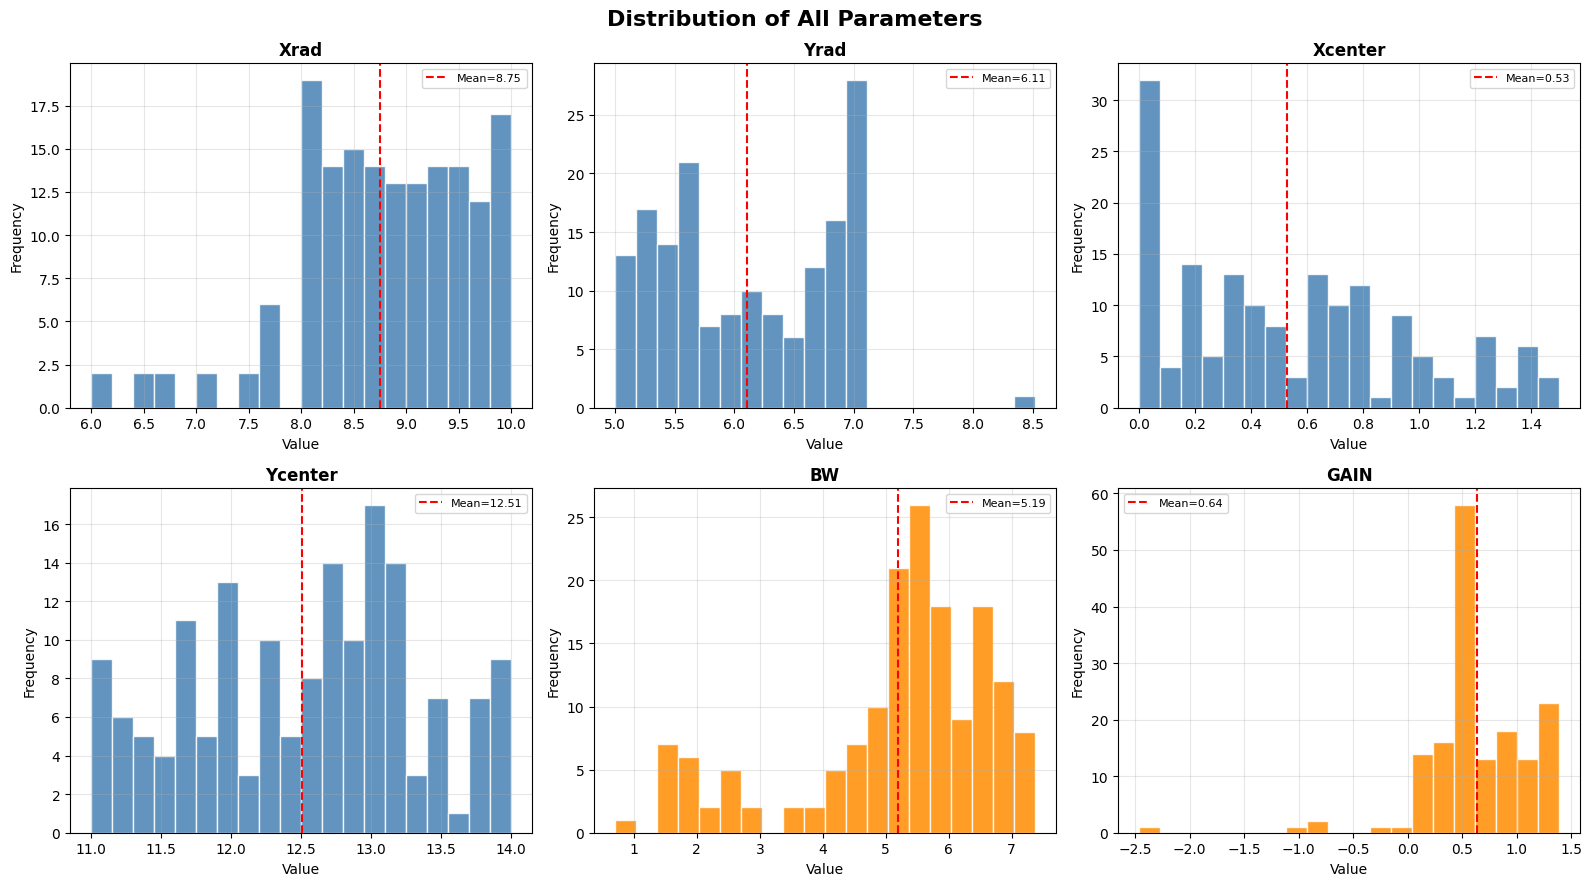

✅ Distribution plots saved.


In [6]:
# ── Distribution Plots ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of All Parameters', fontsize=16, fontweight='bold')

cols = ['Xrad', 'Yrad', 'Xcenter', 'Ycenter', 'BW', 'GAIN']
colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue', 'darkorange', 'darkorange']

for ax, col, color in zip(axes.flat, cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.2f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Distribution plots saved.')

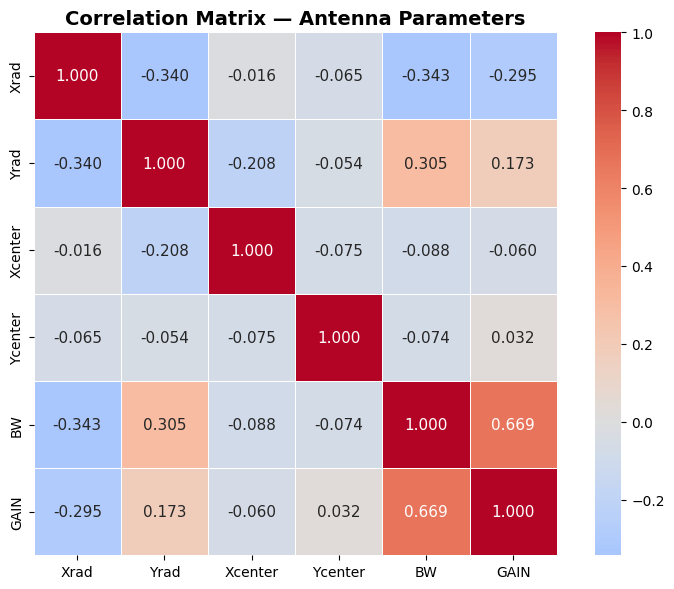

✅ Correlation heatmap saved.


In [7]:
# ── Correlation Heatmap ─────────────────────────────────────────
plt.figure(figsize=(8, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 11})
plt.title('Correlation Matrix — Antenna Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap saved.')

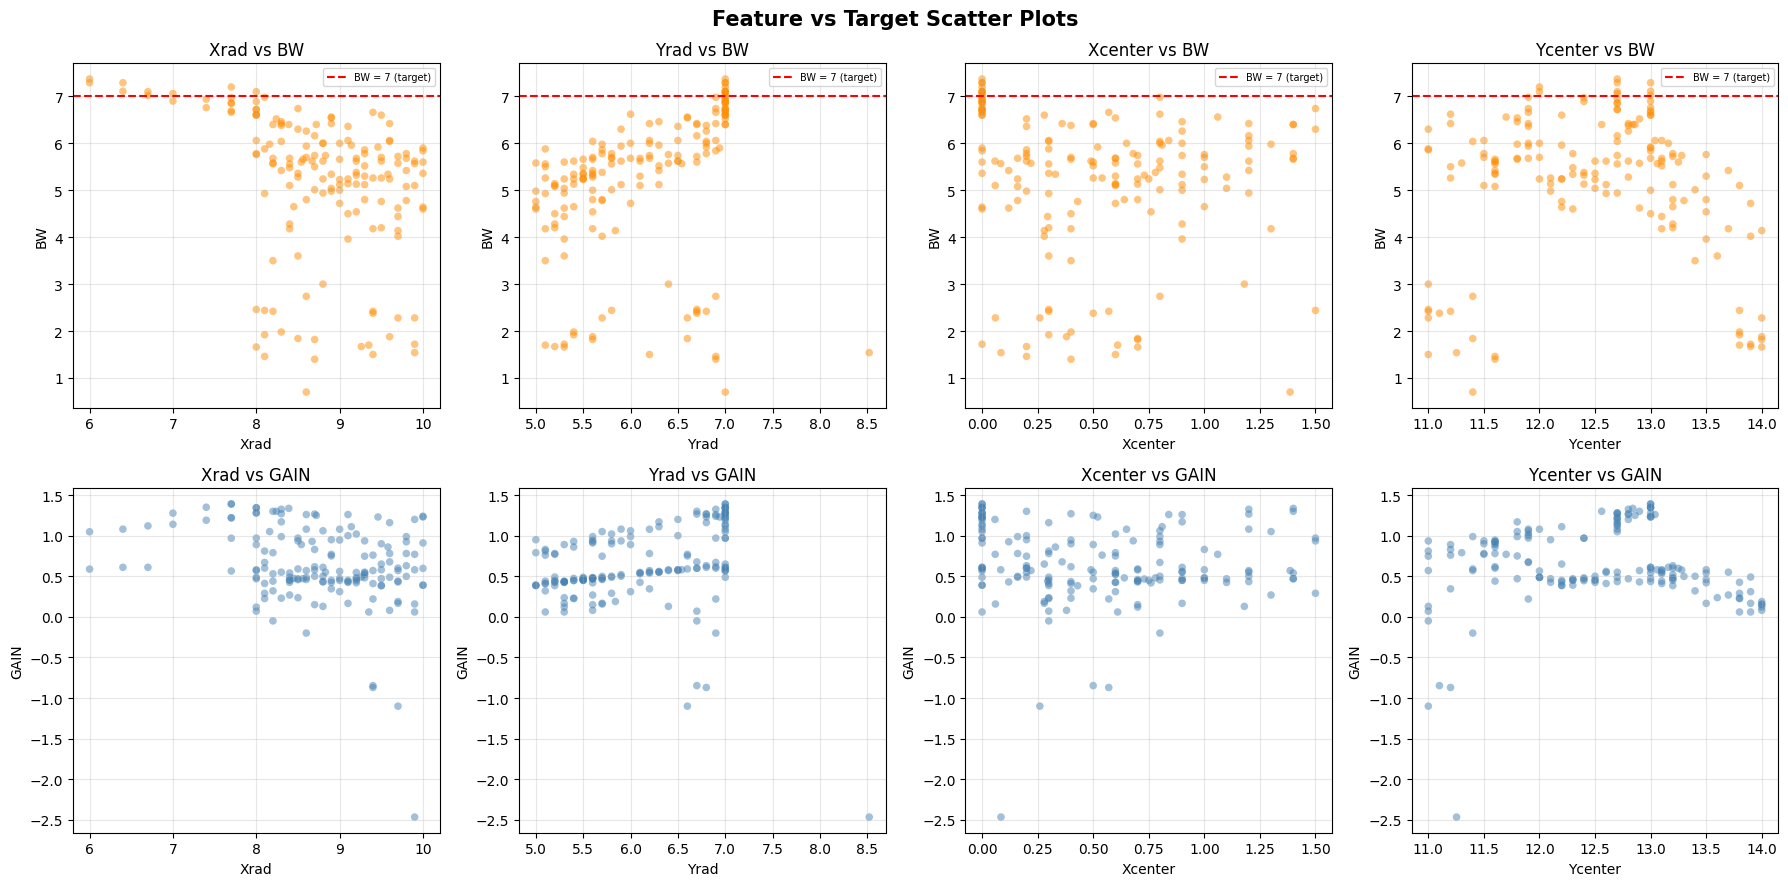

✅ Scatter plots saved.


In [8]:
# ── Scatter: each feature vs BW and GAIN ───────────────────────
features = ['Xrad', 'Yrad', 'Xcenter', 'Ycenter']
targets  = ['BW', 'GAIN']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Feature vs Target Scatter Plots', fontsize=15, fontweight='bold')

target_colors = ['darkorange', 'steelblue']

for row, (target, color) in enumerate(zip(targets, target_colors)):
    for col, feat in enumerate(features):
        ax = axes[row][col]
        ax.scatter(df[feat], df[target], color=color, alpha=0.5, edgecolors='none', s=30)
        if target == 'BW':
            ax.axhline(7, color='red', linestyle='--', linewidth=1.5, label='BW = 7 (target)')
            ax.legend(fontsize=7)
        ax.set_xlabel(feat)
        ax.set_ylabel(target)
        ax.set_title(f'{feat} vs {target}')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Scatter plots saved.')

## 🛠️ Step 4: Data Preprocessing

In [9]:
# Define features and targets
FEATURE_COLS = ['Xrad', 'Yrad', 'Xcenter', 'Ycenter']
TARGET_COLS  = ['BW', 'GAIN']

X = df[FEATURE_COLS].values
y = df[TARGET_COLS].values

# Split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for SVR, MLP, KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train set : {X_train.shape[0]} samples')
print(f'Test set  : {X_test.shape[0]} samples')
print('✅ Preprocessing complete.')

Train set : 128 samples
Test set  : 33 samples
✅ Preprocessing complete.


## 🤖 Step 5: Train & Compare Multiple ML Models

We train **7 models** for each target (BW and GAIN) and select the best one based on R² score and cross-validation.

In [10]:
# ── Define all candidate models ─────────────────────────────────
# Models that need scaled input vs raw input are handled separately
MODELS = {
    'Random Forest'         : (RandomForestRegressor(n_estimators=300, random_state=42),        False),
    'Extra Trees'           : (ExtraTreesRegressor(n_estimators=300, random_state=42),          False),
    'XGBoost'               : (XGBRegressor(n_estimators=300, learning_rate=0.05,
                                            max_depth=5, random_state=42, verbosity=0),         False),
    'Gradient Boosting'     : (GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                            max_depth=4, random_state=42),                      False),
    'SVR (RBF kernel)'      : (SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.01),               True),
    'MLP Neural Network'    : (MLPRegressor(hidden_layer_sizes=(128, 64, 32),
                                            activation='relu', max_iter=2000,
                                            learning_rate='adaptive', random_state=42),         True),
    'K-Nearest Neighbors'   : (KNeighborsRegressor(n_neighbors=5, weights='distance'),          True),
}

# ── Training & evaluation loop ───────────────────────────────────
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Training models — please wait...\n')
print(f'{"Model":<25} {"Target":<8} {"R²":>7} {"RMSE":>8} {"MAE":>8} {"CV R² (5-fold)":>16}')
print('-' * 72)

for name, (model_template, needs_scale) in MODELS.items():
    results[name] = {}
    for t_idx, target in enumerate(TARGET_COLS):
        import copy
        model = copy.deepcopy(model_template)

        Xtr = X_train_sc if needs_scale else X_train
        Xte = X_test_sc  if needs_scale else X_test
        Xall = np.vstack([Xtr, Xte])
        X_full_sc = X_train_sc if needs_scale else X_train

        ytr = y_train[:, t_idx]
        yte = y_test[:, t_idx]

        # Train
        model.fit(Xtr, ytr)
        y_pred = model.predict(Xte)

        r2   = r2_score(yte, y_pred)
        rmse = np.sqrt(mean_squared_error(yte, y_pred))
        mae  = mean_absolute_error(yte, y_pred)

        # Cross-validation on full data
        X_cv = X_train_sc if needs_scale else X_train
        cv_scores = cross_val_score(model, X_cv, ytr, cv=kfold, scoring='r2')
        cv_mean = cv_scores.mean()

        results[name][target] = {
            'model': model, 'r2': r2, 'rmse': rmse,
            'mae': mae, 'cv_r2': cv_mean, 'needs_scale': needs_scale
        }

        print(f'{name:<25} {target:<8} {r2:>7.4f} {rmse:>8.4f} {mae:>8.4f} {cv_mean:>16.4f}')
    print()

print('✅ All models trained and evaluated.')

Training models — please wait...

Model                     Target        R²     RMSE      MAE   CV R² (5-fold)
------------------------------------------------------------------------
Random Forest             BW        0.7821   0.6836   0.3036           0.7219
Random Forest             GAIN      0.4767   0.3385   0.1995           0.5546

Extra Trees               BW        0.7838   0.6810   0.3143           0.7800
Extra Trees               GAIN      0.7930   0.2129   0.1453           0.6631

XGBoost                   BW        0.6794   0.8291   0.3009           0.7447
XGBoost                   GAIN      0.5538   0.3125   0.1670           0.6025

Gradient Boosting         BW        0.6630   0.8501   0.3124           0.7933
Gradient Boosting         GAIN      0.5197   0.3243   0.1794           0.6292

SVR (RBF kernel)          BW        0.8691   0.5298   0.2539           0.6306
SVR (RBF kernel)          GAIN      0.7721   0.2234   0.1585           0.6427

MLP Neural Network        BW  

In [11]:
# ── Select the BEST model for each target ───────────────────────
best_models = {}
print('='*55)
print('       BEST MODEL SELECTION (by Test R²)')
print('='*55)

for target in TARGET_COLS:
    best_name = max(results, key=lambda n: results[n][target]['r2'])
    best_r2   = results[best_name][target]['r2']
    best_cv   = results[best_name][target]['cv_r2']
    best_models[target] = results[best_name][target]
    best_models[target]['name'] = best_name
    print(f'\n🏆 Best model for {target}: {best_name}')
    print(f'   Test R² = {best_r2:.4f} | CV R² = {best_cv:.4f}')

       BEST MODEL SELECTION (by Test R²)

🏆 Best model for BW: SVR (RBF kernel)
   Test R² = 0.8691 | CV R² = 0.6306

🏆 Best model for GAIN: Extra Trees
   Test R² = 0.7930 | CV R² = 0.6631


## 📊 Step 6: Model Comparison Visualization

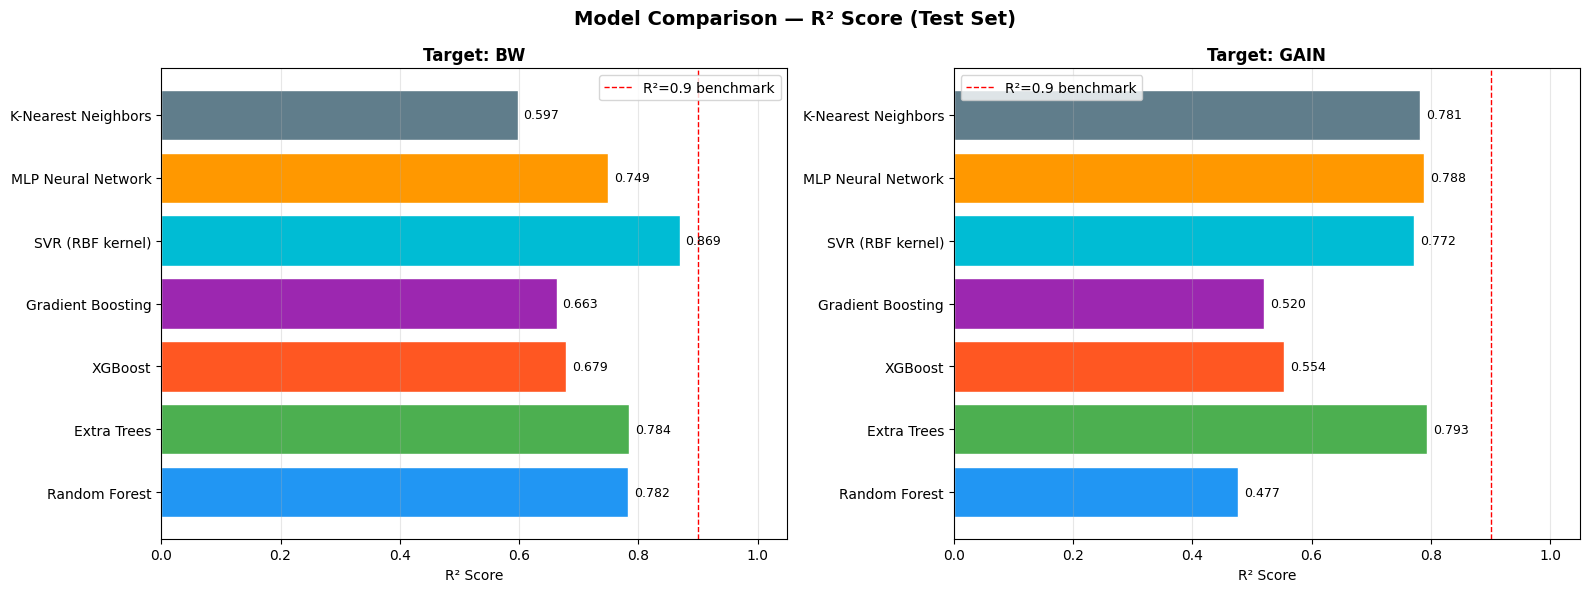

✅ Model comparison chart saved.


In [12]:
# ── R² Comparison Bar Chart ─────────────────────────────────────
model_names = list(MODELS.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — R² Score (Test Set)', fontsize=14, fontweight='bold')

bar_colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#00BCD4', '#FF9800', '#607D8B']

for ax, target in zip(axes, TARGET_COLS):
    r2_vals = [results[n][target]['r2'] for n in model_names]
    bars = ax.barh(model_names, r2_vals, color=bar_colors, edgecolor='white')
    ax.set_title(f'Target: {target}', fontweight='bold')
    ax.set_xlabel('R² Score')
    ax.set_xlim(0, 1.05)
    ax.axvline(0.9, color='red', linestyle='--', linewidth=1, label='R²=0.9 benchmark')
    ax.legend()
    for bar, val in zip(bars, r2_vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison chart saved.')

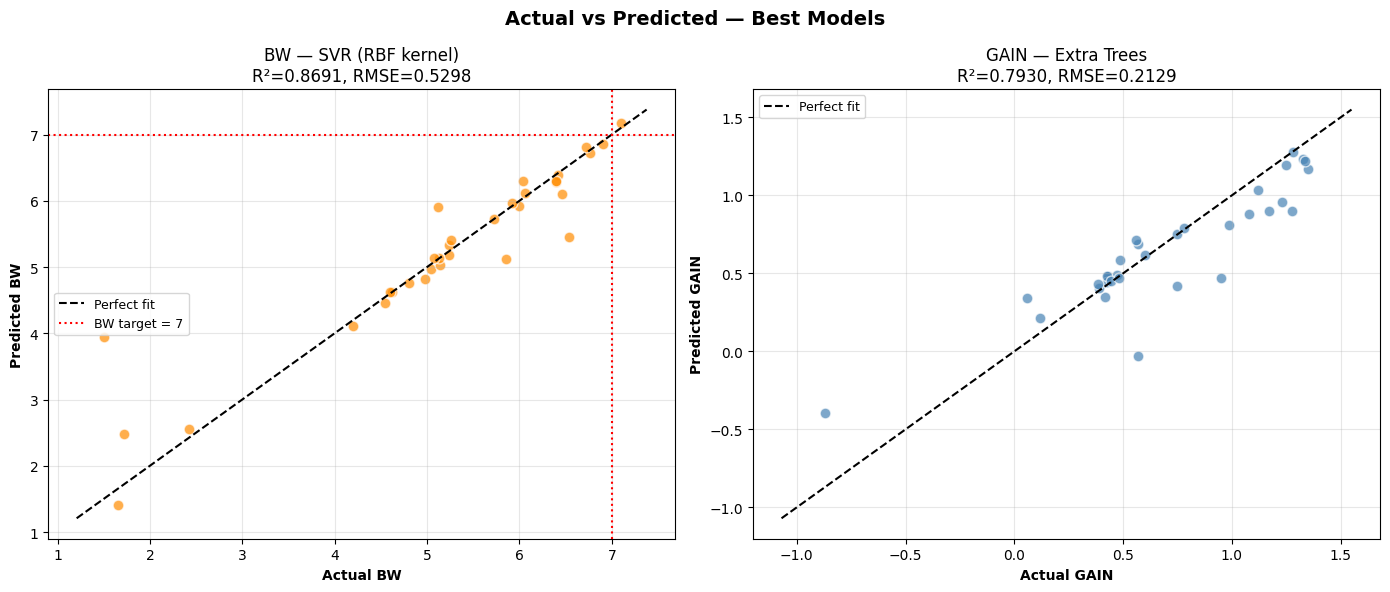

✅ Actual vs Predicted plots saved.


In [13]:
# ── Actual vs Predicted plots for best models ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actual vs Predicted — Best Models', fontsize=14, fontweight='bold')

colors = ['darkorange', 'steelblue']

for ax, target, color, t_idx in zip(axes, TARGET_COLS, colors, [0, 1]):
    bm = best_models[target]
    Xte = X_test_sc if bm['needs_scale'] else X_test
    y_pred = bm['model'].predict(Xte)
    yte    = y_test[:, t_idx]

    ax.scatter(yte, y_pred, color=color, alpha=0.7, edgecolors='white', s=60)
    lims = [min(yte.min(), y_pred.min()) - 0.2,
            max(yte.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
    if target == 'BW':
        ax.axhline(7, color='red', linestyle=':', linewidth=1.5, label='BW target = 7')
        ax.axvline(7, color='red', linestyle=':', linewidth=1.5)

    r2 = r2_score(yte, y_pred)
    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    ax.set_xlabel(f'Actual {target}', fontweight='bold')
    ax.set_ylabel(f'Predicted {target}', fontweight='bold')
    ax.set_title(f'{target} — {bm["name"]}\nR²={r2:.4f}, RMSE={rmse:.4f}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Actual vs Predicted plots saved.')

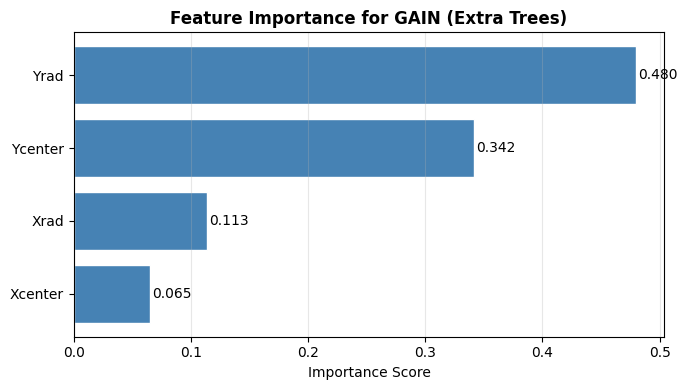

✅ Feature importance plots saved.


In [14]:
# ── Feature Importance (from best tree-based model) ─────────────
# Use whichever best model supports feature_importances_
for target, t_idx in zip(TARGET_COLS, [0, 1]):
    bm = best_models[target]
    model = bm['model']
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        fi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
        fi_df = fi_df.sort_values('Importance', ascending=True)

        fig, ax = plt.subplots(figsize=(7, 4))
        bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
                       color='steelblue' if target=='GAIN' else 'darkorange',
                       edgecolor='white')
        ax.set_title(f'Feature Importance for {target} ({bm["name"]})',
                     fontweight='bold')
        ax.set_xlabel('Importance Score')
        for bar, val in zip(bars, fi_df['Importance']):
            ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=10)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'feature_importance_{target}.png', dpi=150, bbox_inches='tight')
        plt.show()
print('✅ Feature importance plots saved.')

## 🔮 Step 7: Single-Point Prediction Function

Use this to predict BW and GAIN for **any set of antenna parameters** you enter.

In [15]:
def predict_antenna(xrad, yrad, xcenter, ycenter):
    """
    Predict BW and GAIN for given antenna geometry parameters.

    Parameters:
        xrad     : X-radius  (valid range: 6.0 – 10.0)
        yrad     : Y-radius  (valid range: 5.0 – 8.52)
        xcenter  : X-center  (valid range: 0.0 – 1.5)
        ycenter  : Y-center  (valid range: 11.0 – 14.0)

    Returns:
        dict with predicted BW and GAIN
    """
    inp = np.array([[xrad, yrad, xcenter, ycenter]])
    inp_sc = scaler.transform(inp)

    preds = {}
    for target in TARGET_COLS:
        bm = best_models[target]
        x_in = inp_sc if bm['needs_scale'] else inp
        preds[target] = float(bm['model'].predict(x_in)[0])

    print('\n' + '='*45)
    print('         ANTENNA PREDICTION RESULT')
    print('='*45)
    print(f'  Input  →  Xrad={xrad}, Yrad={yrad}, Xcenter={xcenter}, Ycenter={ycenter}')
    print(f'  Predicted BW   : {preds["BW"]:.4f}'  +
          ('  ✅ Above 7!' if preds['BW'] > 7 else '  ⚠️  Below 7 target'))
    print(f'  Predicted GAIN : {preds["GAIN"]:.4f} dBi')
    print('='*45)
    return preds


# ── Example prediction ──────────────────────────────────────────
# 👉 Change these values to test any antenna configuration
predict_antenna(xrad=6.0, yrad=7.0, xcenter=0.0, ycenter=12.7)


         ANTENNA PREDICTION RESULT
  Input  →  Xrad=6.0, Yrad=7.0, Xcenter=0.0, Ycenter=12.7
  Predicted BW   : 7.3801  ✅ Above 7!
  Predicted GAIN : 1.0480 dBi


{'BW': 7.380124917449869, 'GAIN': 1.0480000000000016}

## ⚙️ Step 8: Multi-Objective Optimization

We use **Differential Evolution** (a global optimizer) to find the combination of  
`Xrad, Yrad, Xcenter, Ycenter` that **maximizes both BW and GAIN equally**,  
with a **hard constraint: BW must be > 7**.

In [16]:
# ── Parameter bounds (from dataset ranges) ───────────────────────
BOUNDS = [
    (df['Xrad'].min(),    df['Xrad'].max()),     # Xrad
    (df['Yrad'].min(),    df['Yrad'].max()),     # Yrad
    (df['Xcenter'].min(), df['Xcenter'].max()),  # Xcenter
    (df['Ycenter'].min(), df['Ycenter'].max()),  # Ycenter
]

# ── Normalize helpers for combined objective ─────────────────────
BW_RANGE   = df['BW'].max()   - df['BW'].min()
GAIN_RANGE = df['GAIN'].max() - df['GAIN'].min()

BW_MIN_TARGET = 7.0   # Hard constraint — BW must be at least this
PENALTY = 1e6         # Heavy penalty for violating the BW constraint

from scipy.spatial.distance import cdist

def objective(params):

    xrad, yrad, xcenter, ycenter = params

    inp = np.array([[xrad, yrad, xcenter, ycenter]])
    inp_sc = scaler.transform(inp)

    bw_pred, gain_pred = [], []

    for target, lst in zip(TARGET_COLS, [bw_pred, gain_pred]):
        bm = best_models[target]
        x_in = inp_sc if bm['needs_scale'] else inp
        lst.append(float(bm['model'].predict(x_in)[0]))

    bw   = bw_pred[0]
    gain = gain_pred[0]

    # Hard BW constraint
    if bw < 7:
        return 1e6 * (7 - bw)

    # Normalize outputs
    bw_norm = (bw - df['BW'].min()) / BW_RANGE
    gain_norm = (gain - df['GAIN'].min()) / GAIN_RANGE

    # Distance penalty from real dataset
    dist = np.min(cdist(inp, X))

    realism_penalty = 0.15 * dist

    # Weighted optimization
    score = (
        0.6 * bw_norm +
        0.4 * gain_norm
    )

    return -(score - realism_penalty)


print('🔍 Running optimization — this may take 30–60 seconds...\n')

result = differential_evolution(
    objective,
    bounds=BOUNDS,
    seed=42,
    maxiter=1000,
    popsize=20,
    tol=1e-9,
    mutation=(0.5, 1.5),
    recombination=0.9,
    polish=True,
    disp=False,
)

print('✅ Optimization complete!')

🔍 Running optimization — this may take 30–60 seconds...

✅ Optimization complete!


In [17]:
# ── Display Optimization Results ────────────────────────────────
opt_params = result.x
opt_xrad, opt_yrad, opt_xcenter, opt_ycenter = opt_params

# Get predicted outputs at optimal point
opt_inp    = np.array([opt_params])
opt_inp_sc = scaler.transform(opt_inp)

opt_bw, opt_gain = [], []
for target, lst in zip(TARGET_COLS, [opt_bw, opt_gain]):
    bm = best_models[target]
    x_in = opt_inp_sc if bm['needs_scale'] else opt_inp
    lst.append(float(bm['model'].predict(x_in)[0]))

opt_bw   = opt_bw[0]
opt_gain = opt_gain[0]

print('\n' + '='*55)
print('        🏆 OPTIMIZED ANTENNA PARAMETERS')
print('='*55)
print(f'  Xrad    (X-radius)  : {opt_xrad:.4f}')
print(f'  Yrad    (Y-radius)  : {opt_yrad:.4f}')
print(f'  Xcenter (X-center)  : {opt_xcenter:.4f}')
print(f'  Ycenter (Y-center)  : {opt_ycenter:.4f}')
print('-'*55)
print(f'  Predicted BW        : {opt_bw:.4f}' +
      ('  ✅ ABOVE TARGET (>7)' if opt_bw > 7 else '  ⚠️  Below 7!'))
print(f'  Predicted GAIN      : {opt_gain:.4f} dBi')
print('='*55)

# Compare with best sample in actual data
df_sorted = df.sort_values(by=['BW', 'GAIN'], ascending=False)
best_row = df_sorted.iloc[0]
print('\n📋 Best actual sample from your dataset:')
print(best_row.to_string())

# Improvement check
bw_improvement   = ((opt_bw   - best_row['BW'])   / best_row['BW'])   * 100
gain_improvement = ((opt_gain - best_row['GAIN']) / best_row['GAIN']) * 100
print(f'\n📈 Improvement over best sample:')
print(f'   BW   : {bw_improvement:+.2f}%')
print(f'   GAIN : {gain_improvement:+.2f}%')


        🏆 OPTIMIZED ANTENNA PARAMETERS
  Xrad    (X-radius)  : 6.0000
  Yrad    (Y-radius)  : 7.0002
  Xcenter (X-center)  : 0.0015
  Ycenter (Y-center)  : 12.6999
-------------------------------------------------------
  Predicted BW        : 7.3815  ✅ ABOVE TARGET (>7)
  Predicted GAIN      : 1.0505 dBi

📋 Best actual sample from your dataset:
Xrad       6.0000
Yrad       7.0000
Xcenter    0.0000
Ycenter   12.7000
BW         7.3700
GAIN       1.0480

📈 Improvement over best sample:
   BW   : +0.16%
   GAIN : +0.23%


In [18]:
# ── Top-10 Candidates from Dataset ──────────────────────────────
# Show existing data points with BW >= 7, sorted by BW+GAIN combined score
df_bw7 = df[df['BW'] >= 7.0].copy()
df_bw7['BW_norm']   = (df_bw7['BW']   - df['BW'].min())   / BW_RANGE
df_bw7['GAIN_norm'] = (df_bw7['GAIN'] - df['GAIN'].min()) / GAIN_RANGE
df_bw7['Score']     = df_bw7['BW_norm'] + df_bw7['GAIN_norm']
df_top = df_bw7.sort_values('Score', ascending=False).drop(
    columns=['BW_norm', 'GAIN_norm', 'Score']).head(10)

print('\n🔝 Top Antenna Configurations from Dataset (BW ≥ 7, sorted by BW+GAIN score):')
display(df_top.reset_index(drop=True))


🔝 Top Antenna Configurations from Dataset (BW ≥ 7, sorted by BW+GAIN score):


,Xrad,Yrad,Xcenter,Ycenter,BW,GAIN
0,6.0000,7.0000,0.0000,12.7000,7.3700,1.0480
1,6.4000,7.0000,0.0000,12.7000,7.2900,1.0800
2,6.7000,7.0000,0.0000,12.7000,7.1000,1.1200
3,7.0000,7.0000,0.0000,12.7000,7.0600,1.1400
4,6.0000,7.0000,0.0000,13.0000,7.2900,0.5880
5,7.7000,7.0000,0.0000,12.0000,7.2000,0.5650
6,6.4000,7.0000,0.0000,13.0000,7.1100,0.6100
7,6.7000,7.0000,0.0000,13.0000,7.0200,0.6100
8,8.0000,7.0000,0.0000,12.0000,7.1000,0.4870


## 📈 Step 9: Optimization Visualization

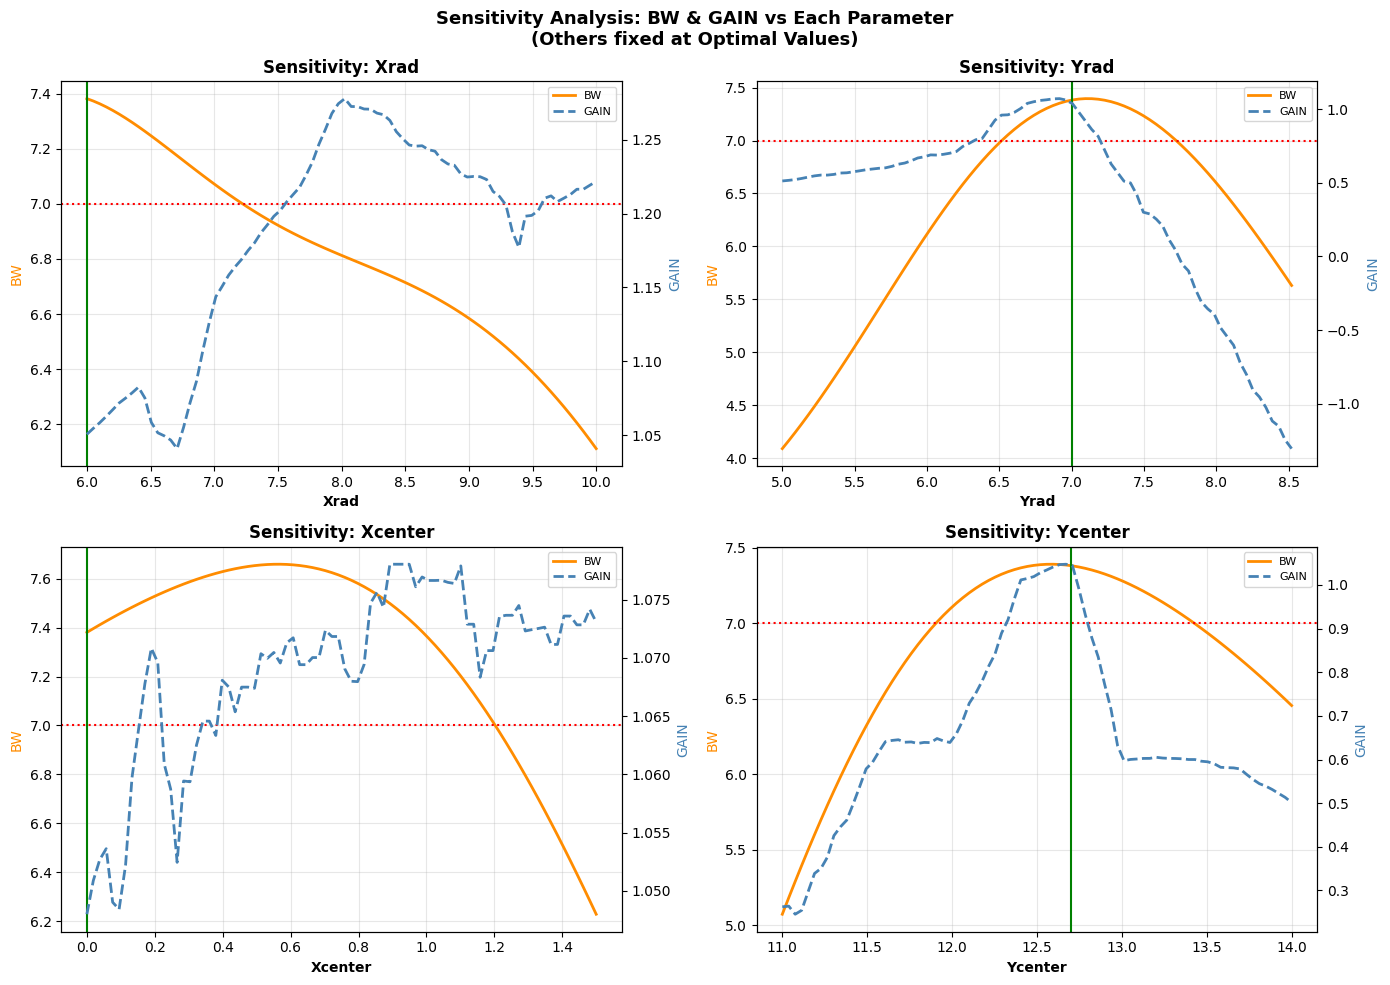

✅ Sensitivity analysis saved.


In [19]:
# ── Sensitivity Analysis: vary each parameter around optimal ─────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sensitivity Analysis: BW & GAIN vs Each Parameter\n(Others fixed at Optimal Values)',
             fontsize=13, fontweight='bold')

param_labels = ['Xrad', 'Yrad', 'Xcenter', 'Ycenter']
opt_vals     = [opt_xrad, opt_yrad, opt_xcenter, opt_ycenter]
bounds_list  = BOUNDS

for idx, (ax, label, opt_v, (lo, hi)) in enumerate(
        zip(axes.flat, param_labels, opt_vals, bounds_list)):

    sweep = np.linspace(lo, hi, 80)
    bw_vals, gain_vals = [], []

    for val in sweep:
        p = np.array(opt_vals.copy())
        p[idx] = val
        inp    = p.reshape(1, -1)
        inp_sc = scaler.transform(inp)

        row_bw, row_gain = [], []
        for target, lst in zip(TARGET_COLS, [row_bw, row_gain]):
            bm = best_models[target]
            x_in = inp_sc if bm['needs_scale'] else inp
            lst.append(float(bm['model'].predict(x_in)[0]))
        bw_vals.append(row_bw[0])
        gain_vals.append(row_gain[0])

    ax2 = ax.twinx()
    l1, = ax.plot(sweep, bw_vals,   color='darkorange', linewidth=2, label='BW')
    l2, = ax2.plot(sweep, gain_vals, color='steelblue',  linewidth=2, linestyle='--', label='GAIN')
    ax.axhline(7, color='red', linestyle=':', linewidth=1.5, label='BW=7 target')
    ax.axvline(opt_v, color='green', linestyle='-', linewidth=1.5, label=f'Optimal={opt_v:.3f}')

    ax.set_xlabel(label, fontweight='bold')
    ax.set_ylabel('BW', color='darkorange')
    ax2.set_ylabel('GAIN', color='steelblue')
    ax.set_title(f'Sensitivity: {label}', fontweight='bold')
    lines = [l1, l2]
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, fontsize=8, loc='best')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sensitivity analysis saved.')

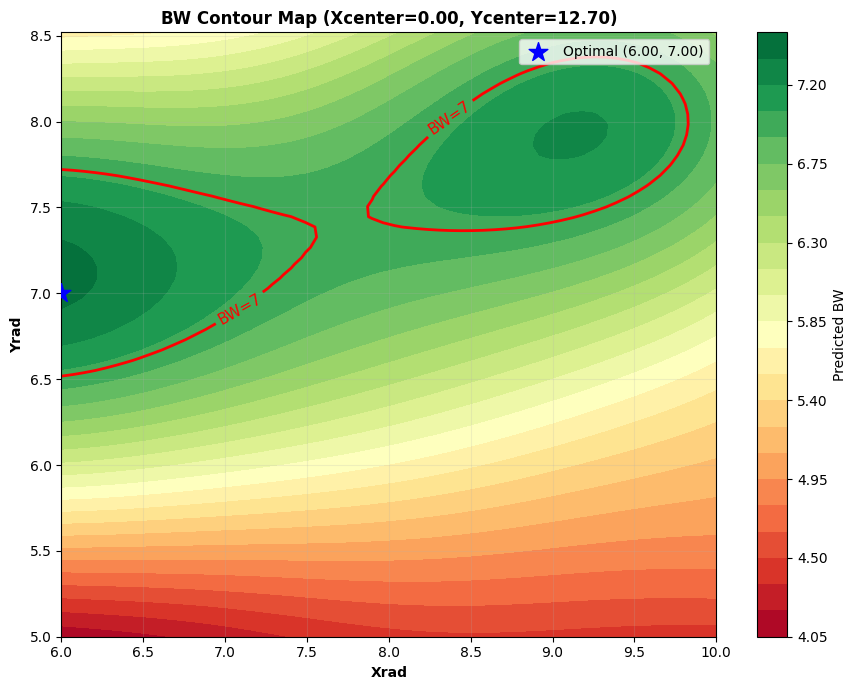

✅ BW contour map saved.


In [20]:
# ── 2D Contour: Xrad vs Yrad for BW (Xcenter, Ycenter at optimal) ──
xr_range = np.linspace(BOUNDS[0][0], BOUNDS[0][1], 60)
yr_range = np.linspace(BOUNDS[1][0], BOUNDS[1][1], 60)
XX, YY  = np.meshgrid(xr_range, yr_range)

grid_pts = np.column_stack([
    XX.ravel(), YY.ravel(),
    np.full(XX.size, opt_xcenter),
    np.full(XX.size, opt_ycenter)
])
grid_sc = scaler.transform(grid_pts)

bm_bw = best_models['BW']
xin   = grid_sc if bm_bw['needs_scale'] else grid_pts
bw_grid = bm_bw['model'].predict(xin).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(9, 7))
cf = ax.contourf(XX, YY, bw_grid, levels=25, cmap='RdYlGn')
cs = ax.contour(XX, YY, bw_grid, levels=[7.0], colors='red', linewidths=2)
ax.clabel(cs, fmt='BW=7', fontsize=11, colors='red')
plt.colorbar(cf, ax=ax, label='Predicted BW')
ax.scatter(opt_xrad, opt_yrad, color='blue', s=200, zorder=5,
           marker='*', label=f'Optimal ({opt_xrad:.2f}, {opt_yrad:.2f})')
ax.set_xlabel('Xrad', fontweight='bold')
ax.set_ylabel('Yrad', fontweight='bold')
ax.set_title(f'BW Contour Map (Xcenter={opt_xcenter:.2f}, Ycenter={opt_ycenter:.2f})',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('bw_contour_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ BW contour map saved.')

## 📋 Step 10: Final Summary Report

In [21]:
print('\n' + '='*65)
print('   📡 FINAL SUMMARY — ANTENNA ML OPTIMIZATION REPORT')
print('='*65)

print('\n📊 DATASET OVERVIEW:')
print(f'   Total samples          : {len(df)}')
print(f'   Samples with BW > 7   : {len(df[df["BW"]>7])}')
print(f'   BW range               : {df["BW"].min():.3f} – {df["BW"].max():.3f}')
print(f'   GAIN range             : {df["GAIN"].min():.3f} – {df["GAIN"].max():.3f}')

print('\n🤖 BEST MODEL PERFORMANCE:')
for target in TARGET_COLS:
    bm = best_models[target]
    bm_name = bm['name']
    Xte = X_test_sc if bm['needs_scale'] else X_test
    t_idx = TARGET_COLS.index(target)
    y_pred = bm['model'].predict(Xte)
    yte    = y_test[:, t_idx]
    r2   = r2_score(yte, y_pred)
    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    mae  = mean_absolute_error(yte, y_pred)
    print(f'\n   Target : {target}')
    print(f'   Model  : {bm_name}')
    print(f'   R²     : {r2:.4f}')
    print(f'   RMSE   : {rmse:.4f}')
    print(f'   MAE    : {mae:.4f}')

print('\n⚙️  OPTIMIZED ANTENNA CONFIGURATION:')
print(f'   Xrad    : {opt_xrad:.4f}')
print(f'   Yrad    : {opt_yrad:.4f}')
print(f'   Xcenter : {opt_xcenter:.4f}')
print(f'   Ycenter : {opt_ycenter:.4f}')

print('\n🏁 PREDICTED OUTPUT AT OPTIMAL POINT:')
print(f'   Bandwidth (BW)  : {opt_bw:.4f}' +
      ('  ✅ TARGET MET (>7)' if opt_bw > 7 else '  ⚠️  Below 7!'))
print(f'   Gain            : {opt_gain:.4f} dBi')

print('\n📁 FILES SAVED IN THIS SESSION:')
for f in ['distribution_plots.png', 'correlation_heatmap.png',
          'scatter_plots.png', 'model_comparison.png',
          'actual_vs_predicted.png', 'feature_importance_BW.png',
          'feature_importance_GAIN.png', 'sensitivity_analysis.png',
          'bw_contour_map.png']:
    print(f'   📌 {f}')

print('\n' + '='*65)
print('   ✅ PROJECT ANALYSIS COMPLETE!')
print('='*65)


   📡 FINAL SUMMARY — ANTENNA ML OPTIMIZATION REPORT

📊 DATASET OVERVIEW:
   Total samples          : 161
   Samples with BW > 7   : 9
   BW range               : 0.700 – 7.370
   GAIN range             : -2.466 – 1.390

🤖 BEST MODEL PERFORMANCE:

   Target : BW
   Model  : SVR (RBF kernel)
   R²     : 0.8691
   RMSE   : 0.5298
   MAE    : 0.2539

   Target : GAIN
   Model  : Extra Trees
   R²     : 0.7930
   RMSE   : 0.2129
   MAE    : 0.1453

⚙️  OPTIMIZED ANTENNA CONFIGURATION:
   Xrad    : 6.0000
   Yrad    : 7.0002
   Xcenter : 0.0015
   Ycenter : 12.6999

🏁 PREDICTED OUTPUT AT OPTIMAL POINT:
   Bandwidth (BW)  : 7.3815  ✅ TARGET MET (>7)
   Gain            : 1.0505 dBi

📁 FILES SAVED IN THIS SESSION:
   📌 distribution_plots.png
   📌 correlation_heatmap.png
   📌 scatter_plots.png
   📌 model_comparison.png
   📌 actual_vs_predicted.png
   📌 feature_importance_BW.png
   📌 feature_importance_GAIN.png
   📌 sensitivity_analysis.png
   📌 bw_contour_map.png

   ✅ PROJECT ANALYSIS COMPLETE

---
## 🧪 Step 11 (Optional): Test Your Own Parameters

Enter any combination of antenna parameters below and get instant BW & GAIN predictions.

In [22]:
# ✏️ Change these values and re-run this cell to test any antenna design
MY_XRAD    = 6.0
MY_YRAD    = 7.0
MY_XCENTER = 0.0
MY_YCENTER = 12.7

predict_antenna(MY_XRAD, MY_YRAD, MY_XCENTER, MY_YCENTER)


         ANTENNA PREDICTION RESULT
  Input  →  Xrad=6.0, Yrad=7.0, Xcenter=0.0, Ycenter=12.7
  Predicted BW   : 7.3801  ✅ Above 7!
  Predicted GAIN : 1.0480 dBi


{'BW': 7.380124917449869, 'GAIN': 1.0480000000000016}